In [11]:
# vae_bells: copy of vae_var + dropout(0.3) after each encoder layer (tunable via `dropout`) + global z-norm of flattened library
## load data


In [12]:
# load the K562 lentiMPRA single-seq ISM (saturation-mutagenesis) maps for one seed
# gradient-corrected (mean-centered across channels) -- analog of hypothetical DeepLIFT
import sys, os, numpy as np, pandas as pd
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
sys.path.append("/grid/koo/home/pmantill/projects/VBI/init_impliment/scripts")
from fast_logo import fast_logo

seam_dir = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
peak = "peak26256"               # top K562 lentiMPRA seed (seam_seeds.csv)

lib    = "100k"                           # <-- switch library size here: "100k" or "200k"
suffix = {"100k": "", "200k": "_200k"}[lib]

with h5py.File(f"{seam_dir}/ism{suffix}/{peak}.h5") as f:
    attributions = f["ism_centered"][:]   # (N, 200, 4) ISM, mean-centered across channels
    predictions  = f["predictions"][:]    # (N,) self-prediction of each mutant

with h5py.File(f"{seam_dir}/mutagenesis_lib{suffix}/{peak}.h5") as f:
    wt_sequence = f["wt_sequence"][:]     # (230, 4) with 15bp adapters

wt_onehot = wt_sequence[15:215]           # variable region matches attributions axis
wt_attr   = attributions[0]               # WT attribution map (index 0)

# flatten: each Lx4 attribution map -> one observation in R^D, D=4L
L = attributions.shape[1]
X = attributions.reshape(attributions.shape[0], -1).astype(np.float32)   # (N, 4L)
X = (X - X.mean()) / (X.std() + 1e-8)      # z-norm the full flattened library (global scalar)
N, D = X.shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_t = torch.from_numpy(X).to(device)
var_data = X.var(0) + 1e-8                 # (D,) global per-dim variance (bg cov seed)
print(f"[{lib}] N={N:,}  D={D} (=4*{L})  device={device}")

[100k] N=100,000  D=800 (=4*200)  device=cuda


In [13]:
# ----- hyperparameters (mixture side matches free_bay_GMM.ipynb: K=200, alpha0=1e-3) -----
J        = 8        # latent (foreground code) dimension  <-- vae_var: halved from 32
K        = 200       # initial number of GMM components (sparse Dirichlet prunes unused)
alpha0   = 1e-3      # Dirichlet concentration (alpha0 < 1 -> sparse -> learns K)
hidden   = 512       # MLP width
dropout  = 0.5       # dropout after each encoder layer  <-- vae_bells: tune here
seed     = 3
torch.manual_seed(seed); rng = np.random.default_rng(seed)

_inv_softplus = lambda y: float(np.log(np.expm1(y)))   # so softplus(raw)=y


class VAE_GMM(nn.Module):
    """VAE over the foreground f=decoder(z); shared bg Gaussian N(mu_b,sigma_b^2) added
    before the reconstruction; GMM(K) prior on z with a Dirichlet(alpha) posterior on pi."""
    def __init__(self, D, J, K, alpha0, hidden, var_data, dropout):
        super().__init__()
        self.D, self.J, self.K, self.alpha0 = D, J, K, alpha0
        # encoder q(z|x)=N(mu_z, diag sigma_z^2); dropout after each layer
        self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout))
        self.enc_mu = nn.Linear(hidden, J)
        self.enc_lv = nn.Linear(hidden, J)
        # decoder p(f|z) -> foreground map in R^D
        self.dec = nn.Sequential(nn.Linear(J, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, D))
        # shared background Gaussian: free mean starts at ZERO. cov is ISOTROPIC -- a single scalar
        # shared across all D dims, like free_bay_GMM (keep bg broad/isotropic).
        self.mu_b     = nn.Parameter(torch.zeros(D))                                  # bg mean starts at 0
        self.log_var_b = nn.Parameter(torch.tensor(0.0))   # scalar -> Sigma_b = sigma_b^2 * I; init log_var_b=0 (mu_b=0 too)
        # GMM prior components in latent space
        self.mu_c     = nn.Parameter(0.1 * torch.randn(K, J))
        self.log_var_c = nn.Parameter(torch.zeros(K, J))
        # q(pi)=Dir(alpha); learn alpha (softplus-positive), init at uniform load alpha0+N/K-ish
        self.alpha_raw = nn.Parameter(torch.full((K,), _inv_softplus(alpha0 + 1.0)))

    @property
    def alpha(self):
        return F.softplus(self.alpha_raw) + 1e-4

    def encode(self, x):
        h = self.enc(x)
        return self.enc_mu(h), self.enc_lv(h)

    def recon_loss(self, x):
        """Warmup objective: reconstruction loss only (no GMM/KL terms). Trains the
        encoder/decoder/background to reconstruct x = decoder(z)+mu_b before clustering."""
        mu_z, lv_z = self.encode(x)
        z = mu_z + torch.randn_like(mu_z) * torch.exp(0.5 * lv_z)
        recon = self.dec(z) + self.mu_b
        log_p_x = -0.5 * (np.log(2*np.pi) + self.log_var_b
                          + (x - recon)**2 * torch.exp(-self.log_var_b)).sum(-1)   # (B,)
        return -log_p_x.mean()

    def forward(self, x, n_total):
        mu_z, lv_z = self.encode(x)                              # (B,J)
        z = mu_z + torch.randn_like(mu_z) * torch.exp(0.5 * lv_z)
        recon = self.dec(z) + self.mu_b                          # f + b  (mean of x)

        # reconstruction: log p(x-b|z) = log N(x; recon, sigma_b^2 I)  (isotropic bg cov; scalar log_var_b broadcasts)
        log_p_x = -0.5 * (np.log(2*np.pi) + self.log_var_b
                          + (x - recon)**2 * torch.exp(-self.log_var_b)).sum(-1)   # (B,)

        # KL[ q(z|x) || N(mu_k,sigma_k^2) ] for every component -> (B,K)
        lv_z_e, mu_z_e = lv_z[:, None, :], mu_z[:, None, :]      # (B,1,J)
        lv_c, mu_c     = self.log_var_c[None], self.mu_c[None]   # (1,K,J)
        KL_k = 0.5 * (lv_c - lv_z_e
                      + (torch.exp(lv_z_e) + (mu_z_e - mu_c)**2) * torch.exp(-lv_c)
                      - 1.0).sum(-1)                              # (B,K)

        alpha   = self.alpha
        Elog_pi = torch.digamma(alpha) - torch.digamma(alpha.sum())   # (K,) E_q[log pi]
        log_un  = Elog_pi[None] - KL_k                                # (B,K)
        log_gamma = log_un - torch.logsumexp(log_un, 1, keepdim=True)
        gamma = log_gamma.exp().detach()                             # responsibilities (E-step)

        klz_term = -(gamma * KL_k).sum(-1)                          # -sum_k gamma_k KL_k
        cat_term = (gamma * (Elog_pi[None] - log_gamma)).sum(-1)    #  sum_k gamma_k log(pi_k/gamma_k)
        elbo_n   = log_p_x + klz_term + cat_term                    # (B,)

        # Dirichlet KL[ q(pi) || Dir(alpha0) ]  (global; scaled per-sample by 1/N)
        kl_pi = (torch.lgamma(alpha.sum()) - torch.lgamma(alpha).sum()
                 - torch.lgamma(torch.tensor(self.K * alpha0, device=x.device))
                 + self.K * torch.lgamma(torch.tensor(alpha0, device=x.device))
                 + ((alpha - alpha0) * Elog_pi).sum())

        loss = -elbo_n.mean() + kl_pi / n_total
        return loss, elbo_n.mean().detach(), gamma

model = VAE_GMM(D, J, K, alpha0, hidden, var_data, dropout).to(device)
print(model)

VAE_GMM(
  (enc): Sequential(
    (0): Linear(in_features=800, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
  )
  (enc_mu): Linear(in_features=512, out_features=8, bias=True)
  (enc_lv): Linear(in_features=512, out_features=8, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=8, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=800, bias=True)
  )
)


loaded cached VAE fit: /grid/koo/home/pmantill/projects/VBI/VAE_gmm/results/peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3.pt  (150 epochs, final ELBO -668.688)


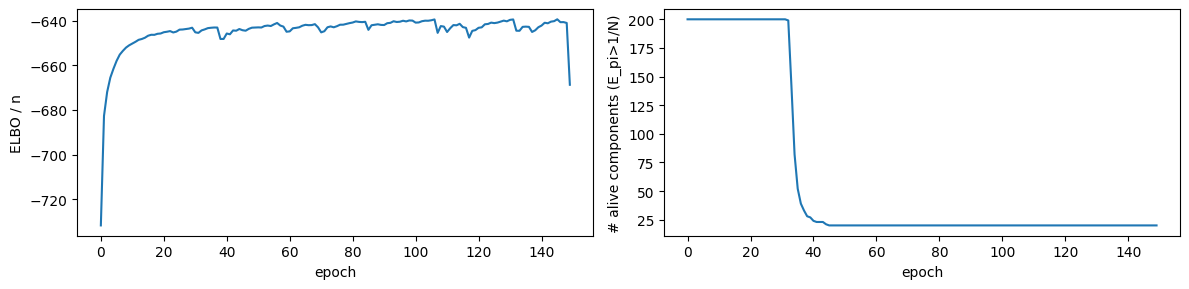

In [14]:
# ----- train (Adam, minibatch); cache by hyperparams like the GMM notebook -----
out_dir = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/results"
os.makedirs(out_dir, exist_ok=True)

epochs, batch, lr = 150, 256, 1e-3
warmup = 100          # epochs of reconstruction-only training before the GMM/ELBO objective

hp_tag   = f"{peak}.{lib}.J{J}.K{K}.a{alpha0:g}.w{warmup}.drop{dropout:g}.znorm.seed{seed}"   # isotropic bg; dropout enc + z-normed lib
ckpt_path = f"{out_dir}/{hp_tag}.pt"

if os.path.exists(ckpt_path):
    ck = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ck["state_dict"]); elbos = ck["elbos"]; n_alive_hist = ck["n_alive_hist"]
    print(f"loaded cached VAE fit: {ckpt_path}  ({len(elbos)} epochs, final ELBO {elbos[-1]:.3f})")
else:
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    # --- warmup: reconstruction loss only (fit encoder/decoder/background before clustering) ---
    for ep in range(warmup):
        perm = torch.randperm(N, device=device)
        ep_rec = 0.0
        model.train()
        for i in range(0, N, batch):
            xb = X_t[perm[i:i+batch]]
            opt.zero_grad()
            rloss = model.recon_loss(xb)
            rloss.backward(); opt.step()
            ep_rec += float(rloss) * xb.shape[0]
        if ep % 10 == 0 or ep == warmup - 1:
            print(f"warmup {ep:3d}  recon_loss/n {ep_rec / N:8.3f}")
    # --- main: full ELBO with the GMM prior ---
    elbos, n_alive_hist = [], []
    for ep in range(epochs):
        perm = torch.randperm(N, device=device)
        ep_elbo = 0.0
        model.train()
        for i in range(0, N, batch):
            xb = X_t[perm[i:i+batch]]
            opt.zero_grad()
            loss, elbo, _ = model(xb, N)
            loss.backward(); opt.step()
            ep_elbo += float(elbo) * xb.shape[0]
        elbos.append(ep_elbo / N)
        with torch.no_grad():
            E_pi = (model.alpha / model.alpha.sum()).cpu().numpy()
        n_alive_hist.append(int((E_pi > 1.0 / N).sum()))
        if ep % 10 == 0 or ep == epochs - 1:
            print(f"epoch {ep:3d}  ELBO/n {elbos[-1]:8.3f}  alive(E_pi>1/N) {n_alive_hist[-1]:3d}")
    torch.save({"state_dict": model.state_dict(), "elbos": elbos, "n_alive_hist": n_alive_hist,
                "hp": dict(peak=peak, lib=lib, J=J, K=K, alpha0=alpha0, warmup=warmup, dropout=dropout, seed=seed)}, ckpt_path)
    print(f"saved -> {ckpt_path}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(elbos);        ax[0].set_xlabel("epoch"); ax[0].set_ylabel("ELBO / n")
ax[1].plot(n_alive_hist); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("# alive components (E_pi>1/N)")
plt.tight_layout(); plt.show()

In [15]:
# ----- responsibilities over the full dataset (E-step, batched, no grad) -----
model.eval()
gammas = []
with torch.no_grad():
    for i in range(0, N, 4096):
        _, _, g = model(X_t[i:i+4096], N)
        gammas.append(g.cpu())
gamma_all = torch.cat(gammas).numpy()            # (N,K)
Nk   = gamma_all.sum(0)                           # (K,) soft counts
hard = gamma_all.argmax(1)                         # (N,) hard assignment
with torch.no_grad():
    alpha = model.alpha.cpu().numpy()
E_pi = alpha / alpha.sum()

pd.DataFrame({
    "Nk_soft": Nk.round(1),
    "Nk_hard": np.bincount(hard, minlength=K),
    "E_pi":    E_pi.round(4),
}).sort_values("Nk_soft", ascending=False)

,Nk_soft,Nk_hard,E_pi
153,10749.400391,10438,0.1071
158,9777.000000,10314,0.0874
56,8434.000000,8609,0.0807
145,7601.899902,7463,0.0773
33,7066.399902,7700,0.0608
...,...,...,...
193,0.000000,0,0.0000
195,0.000000,0,0.0000
196,0.000000,0,0.0000
197,0.000000,0,0.0000


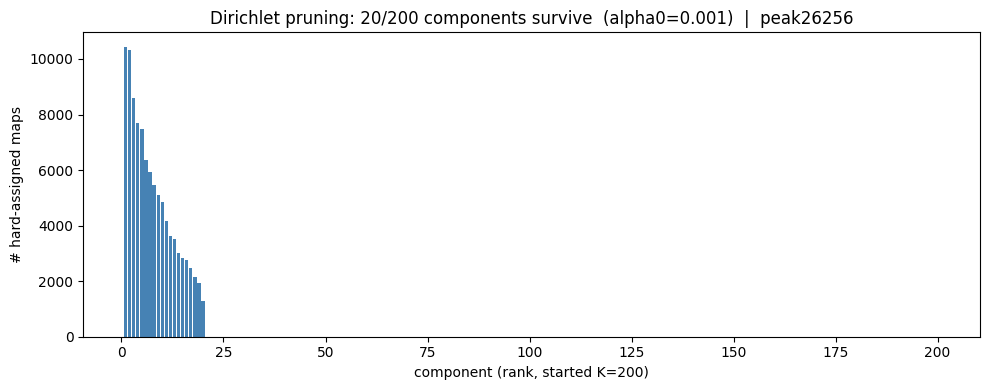

In [16]:
# ----- pruning summary: how many of the K latent components survive -----
hard_counts = np.sort(np.bincount(hard, minlength=K))[::-1]
n_alive = int((hard_counts > 0).sum())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(1, K+1), hard_counts, color="steelblue")
ax.set_xlabel(f"component (rank, started K={K})")
ax.set_ylabel("# hard-assigned maps")
ax.set_title(f"Dirichlet pruning: {n_alive}/{K} components survive  (alpha0={alpha0:g})  |  {peak}")
plt.tight_layout(); plt.show()

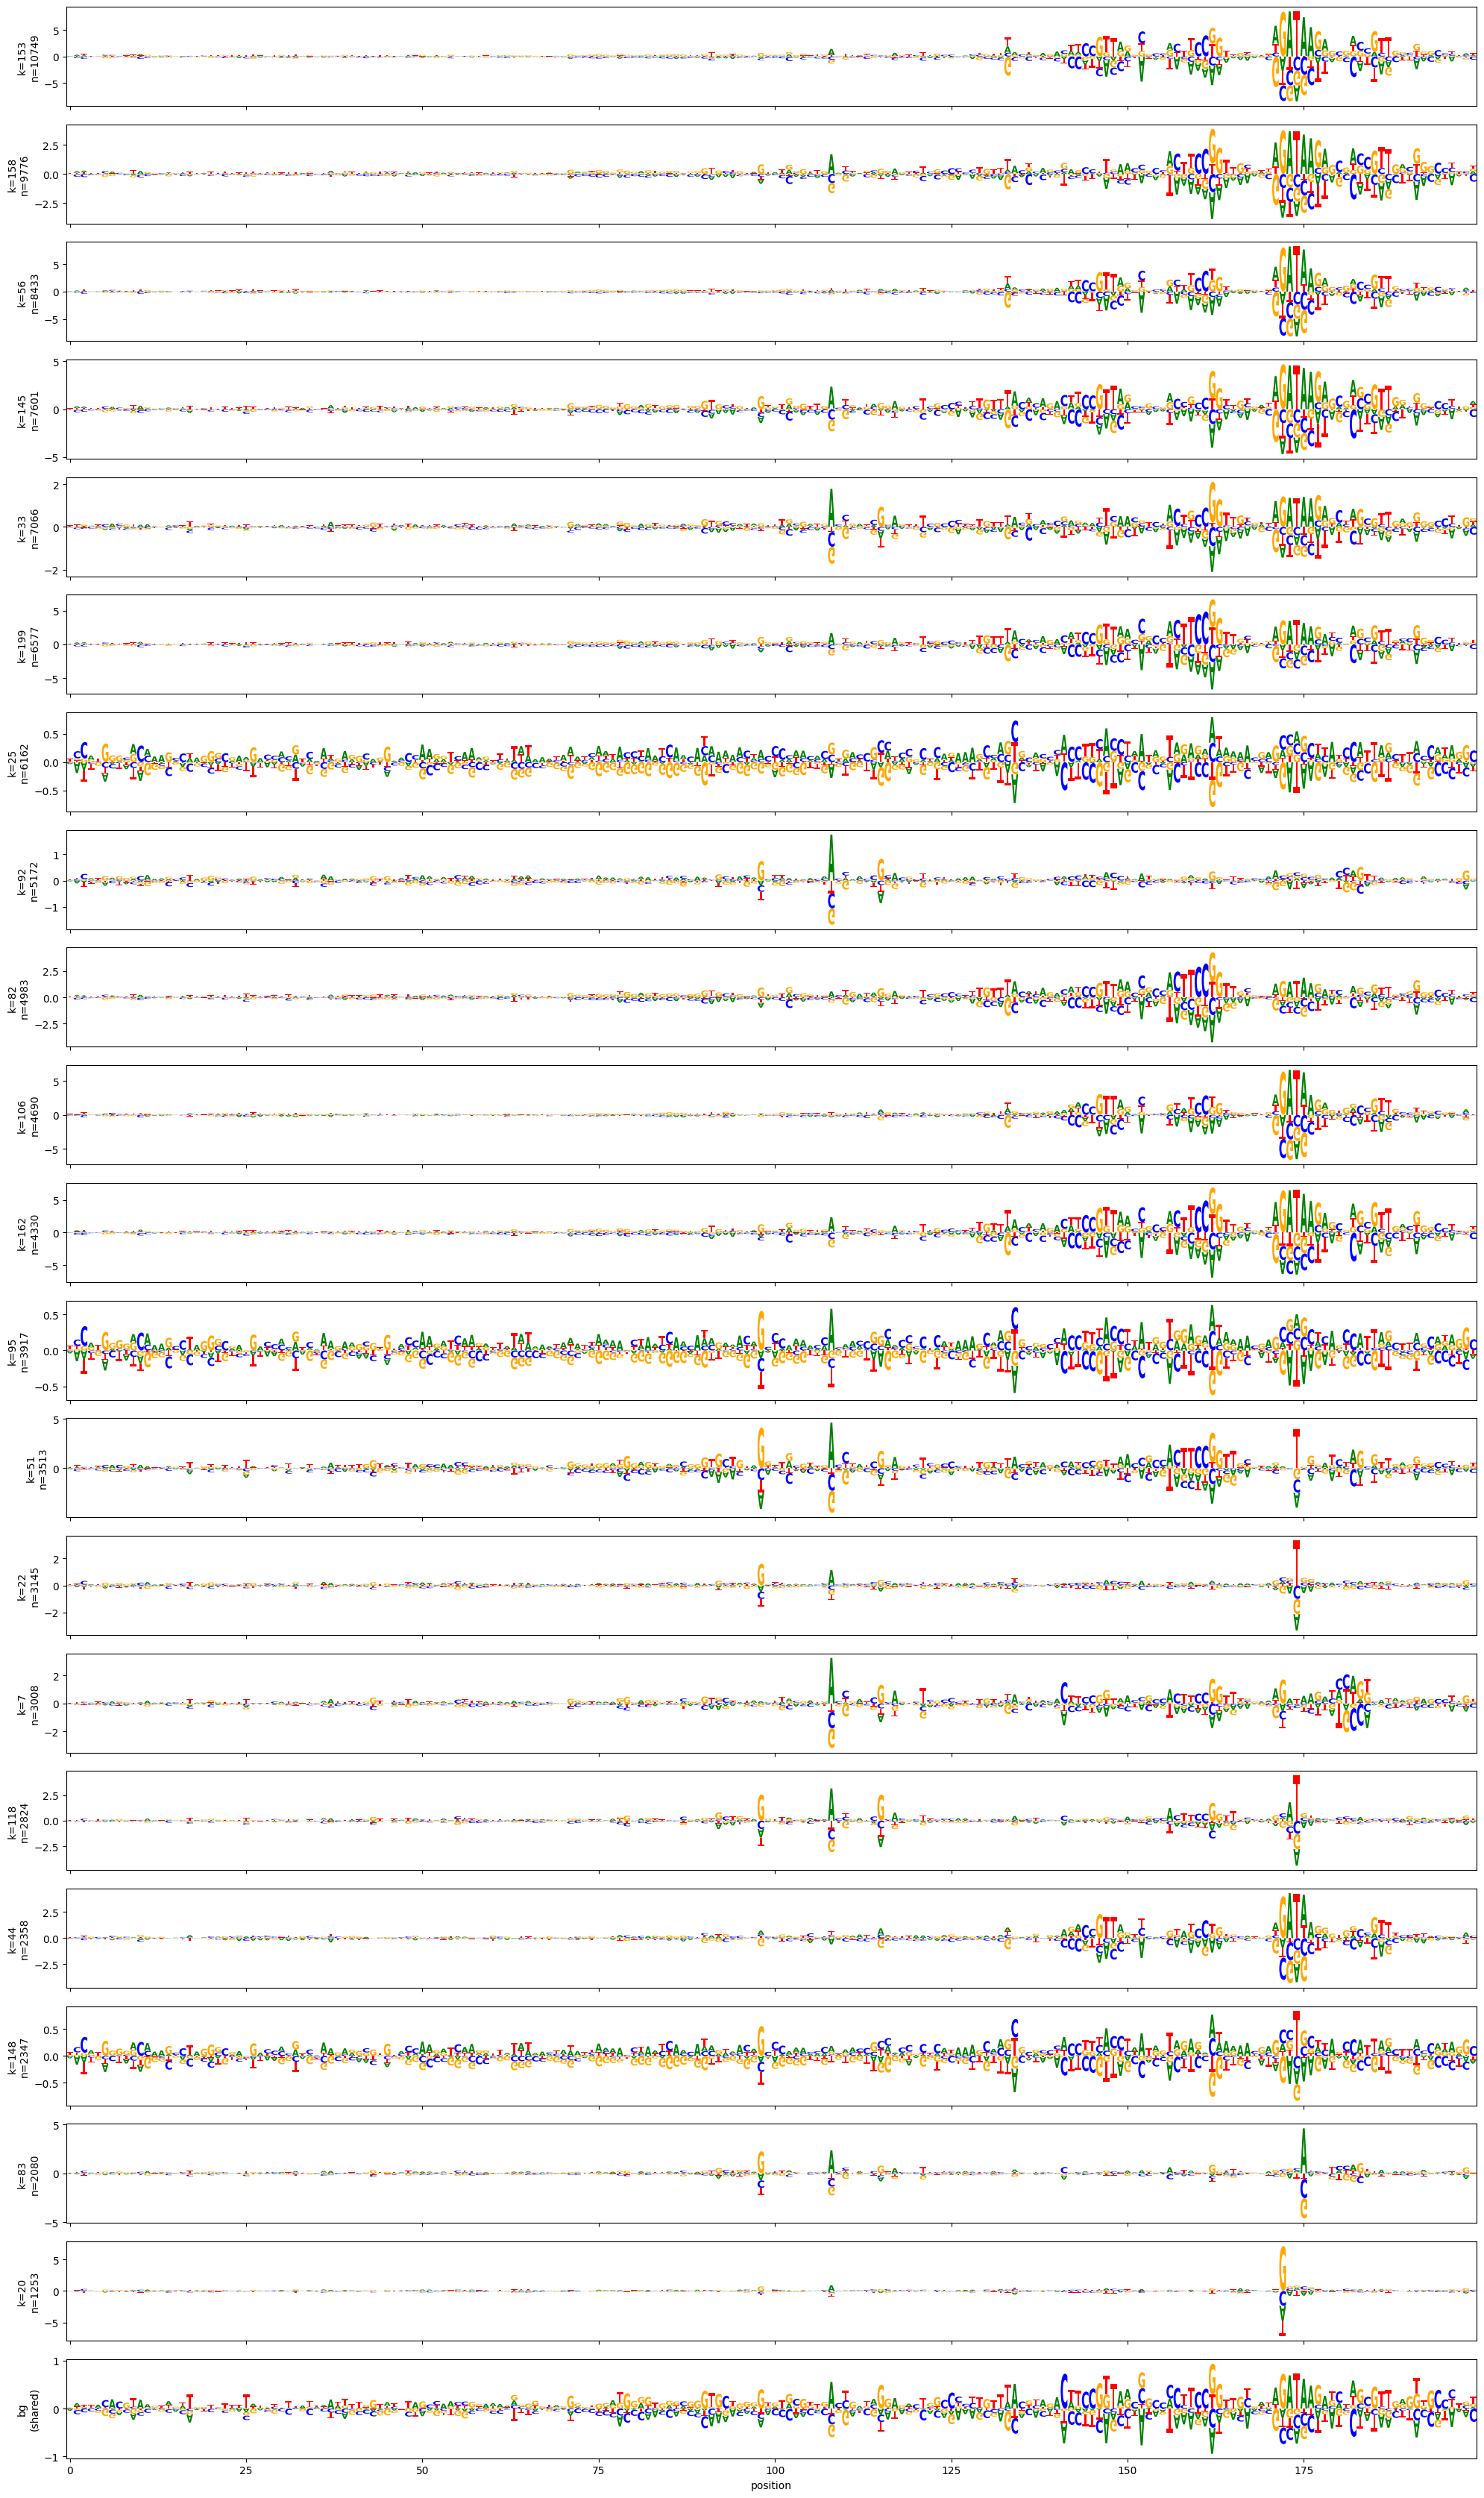

In [17]:
# ----- per-component foreground logos: decode the component mean mu_k -> f_k = decoder(mu_k) -----
# shared background mu_b shown last. Only alive components (largest first).
order = np.argsort(-Nk)
order = [k for k in order if Nk[k] > 1.0]          # drop pruned components
with torch.no_grad():
    fg_means = model.dec(model.mu_c[order].to(device)).cpu().numpy().reshape(len(order), L, 4)
    bg_map   = model.mu_b.detach().cpu().numpy().reshape(L, 4)

fig, axes = plt.subplots(len(order)+1, 1, figsize=(20, 1.6*(len(order)+1)), sharex=True)
axes = np.atleast_1d(axes)
for ax, k, fmap in zip(axes[:-1], order, fg_means):
    fast_logo(fmap, ax=ax)
    ax.set_ylabel(f"k={k}\nn={int(Nk[k])}")
fast_logo(bg_map, ax=axes[-1]); axes[-1].set_ylabel("bg\n(shared)"); axes[-1].set_xlabel("position")
plt.tight_layout(); plt.show()

saved figure -> /grid/koo/home/pmantill/projects/VBI/VAE_gmm/results/figures/peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3.fg_bg_compare.png


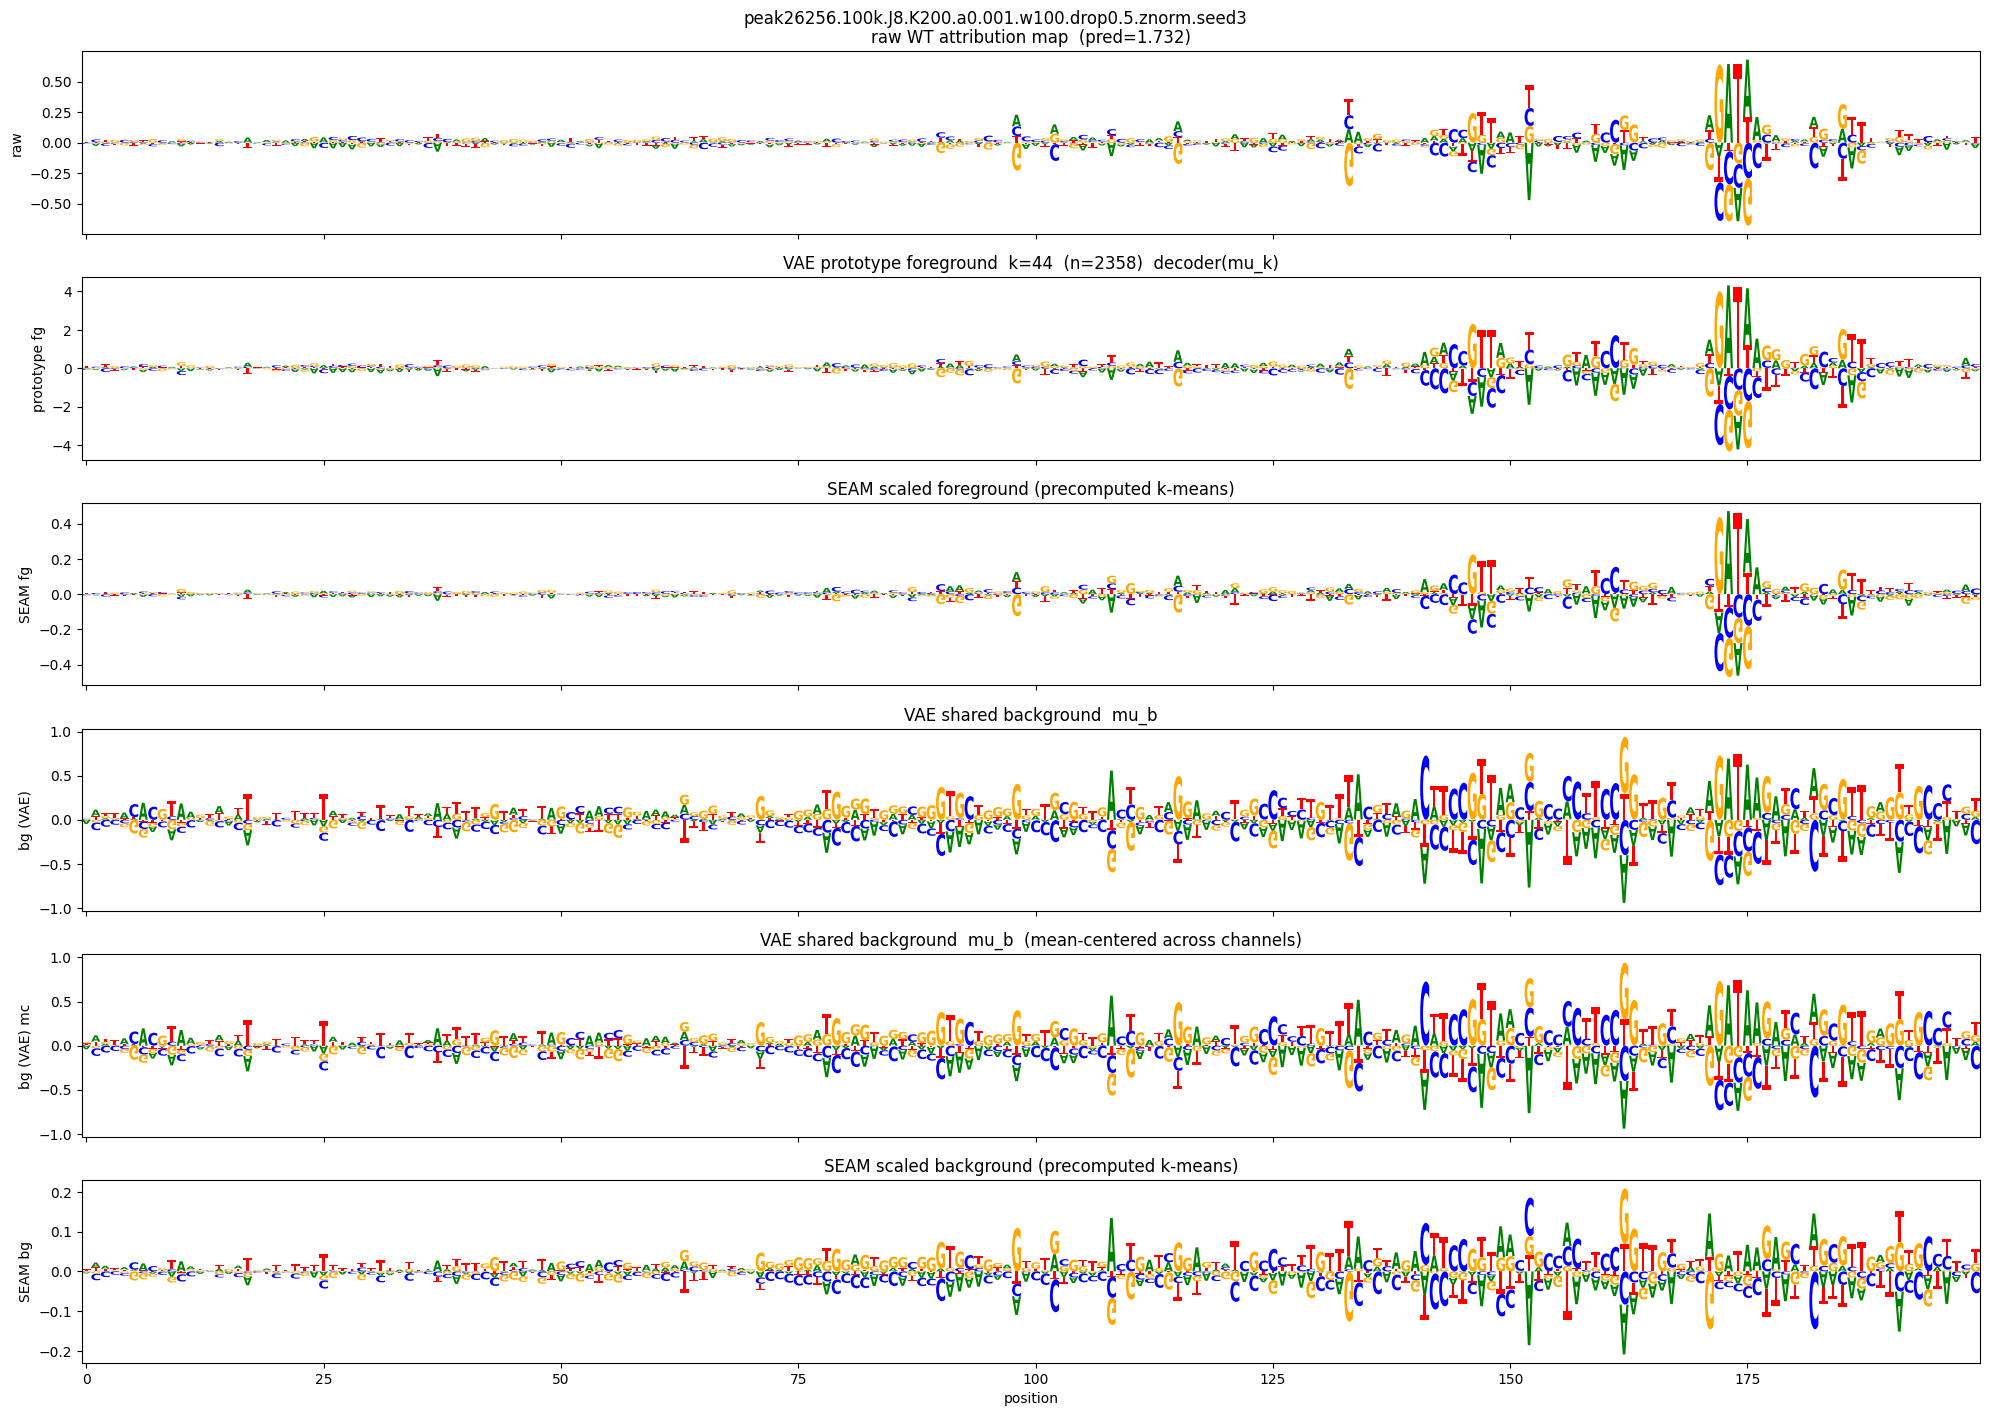

In [18]:
# ----- WT (index 0): raw map vs its cluster's PROTOTYPE foreground, SEAM foreground, background -----
# prototype fg = decoder(mu_k) is the SEAM-foreground analog (cluster-level motif syntax); bg = everything else
k_wt = int(hard[0])
with torch.no_grad():
    proto_fg = model.dec(model.mu_c[k_wt:k_wt+1].to(device)).cpu().numpy().reshape(L, 4)
    bg_mean  = model.mu_b.detach().cpu().numpy().reshape(L, 4)
bg_mean_mc = bg_mean - bg_mean.mean(-1, keepdims=True)   # mu_b mean-centered across channels (just to see)

seam_dir_pk = f"{seam_dir}/foregrounds{suffix}/{peak}"
seam_fg = np.load(f"{seam_dir_pk}/foreground_scaled.npy")                 # SEAM scaled foreground (ref/WT cluster)
seam_bg = np.load(f"{seam_dir_pk}/average_background_scaled.npy")         # SEAM scaled background (ref/WT cluster)

panels = [
    (wt_attr,    "raw",            f"raw WT attribution map  (pred={predictions[0]:.3f})"),
    (proto_fg,   "prototype fg",   f"VAE prototype foreground  k={k_wt}  (n={int(Nk[k_wt])})  decoder(mu_k)"),
    (seam_fg,    "SEAM fg",        "SEAM scaled foreground (precomputed k-means)"),
    (bg_mean,    "bg (VAE)",       "VAE shared background  mu_b"),
    (bg_mean_mc, "bg (VAE) mc",    "VAE shared background  mu_b  (mean-centered across channels)"),
    (seam_bg,    "SEAM bg",        "SEAM scaled background (precomputed k-means)"),
]
fig, axes = plt.subplots(len(panels), 1, figsize=(20, 2.4*len(panels)), sharex=True)
for ax, (m, ylab, title) in zip(axes, panels):
    fast_logo(m, ax=ax); ax.set_ylabel(ylab); ax.set_title(title)
axes[-1].set_xlabel("position")
fig.suptitle(hp_tag)
plt.tight_layout()

fig_dir = f"{out_dir}/figures"; os.makedirs(fig_dir, exist_ok=True)
fig_path = f"{fig_dir}/{hp_tag}.fg_bg_compare.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"saved figure -> {fig_path}")
plt.show()

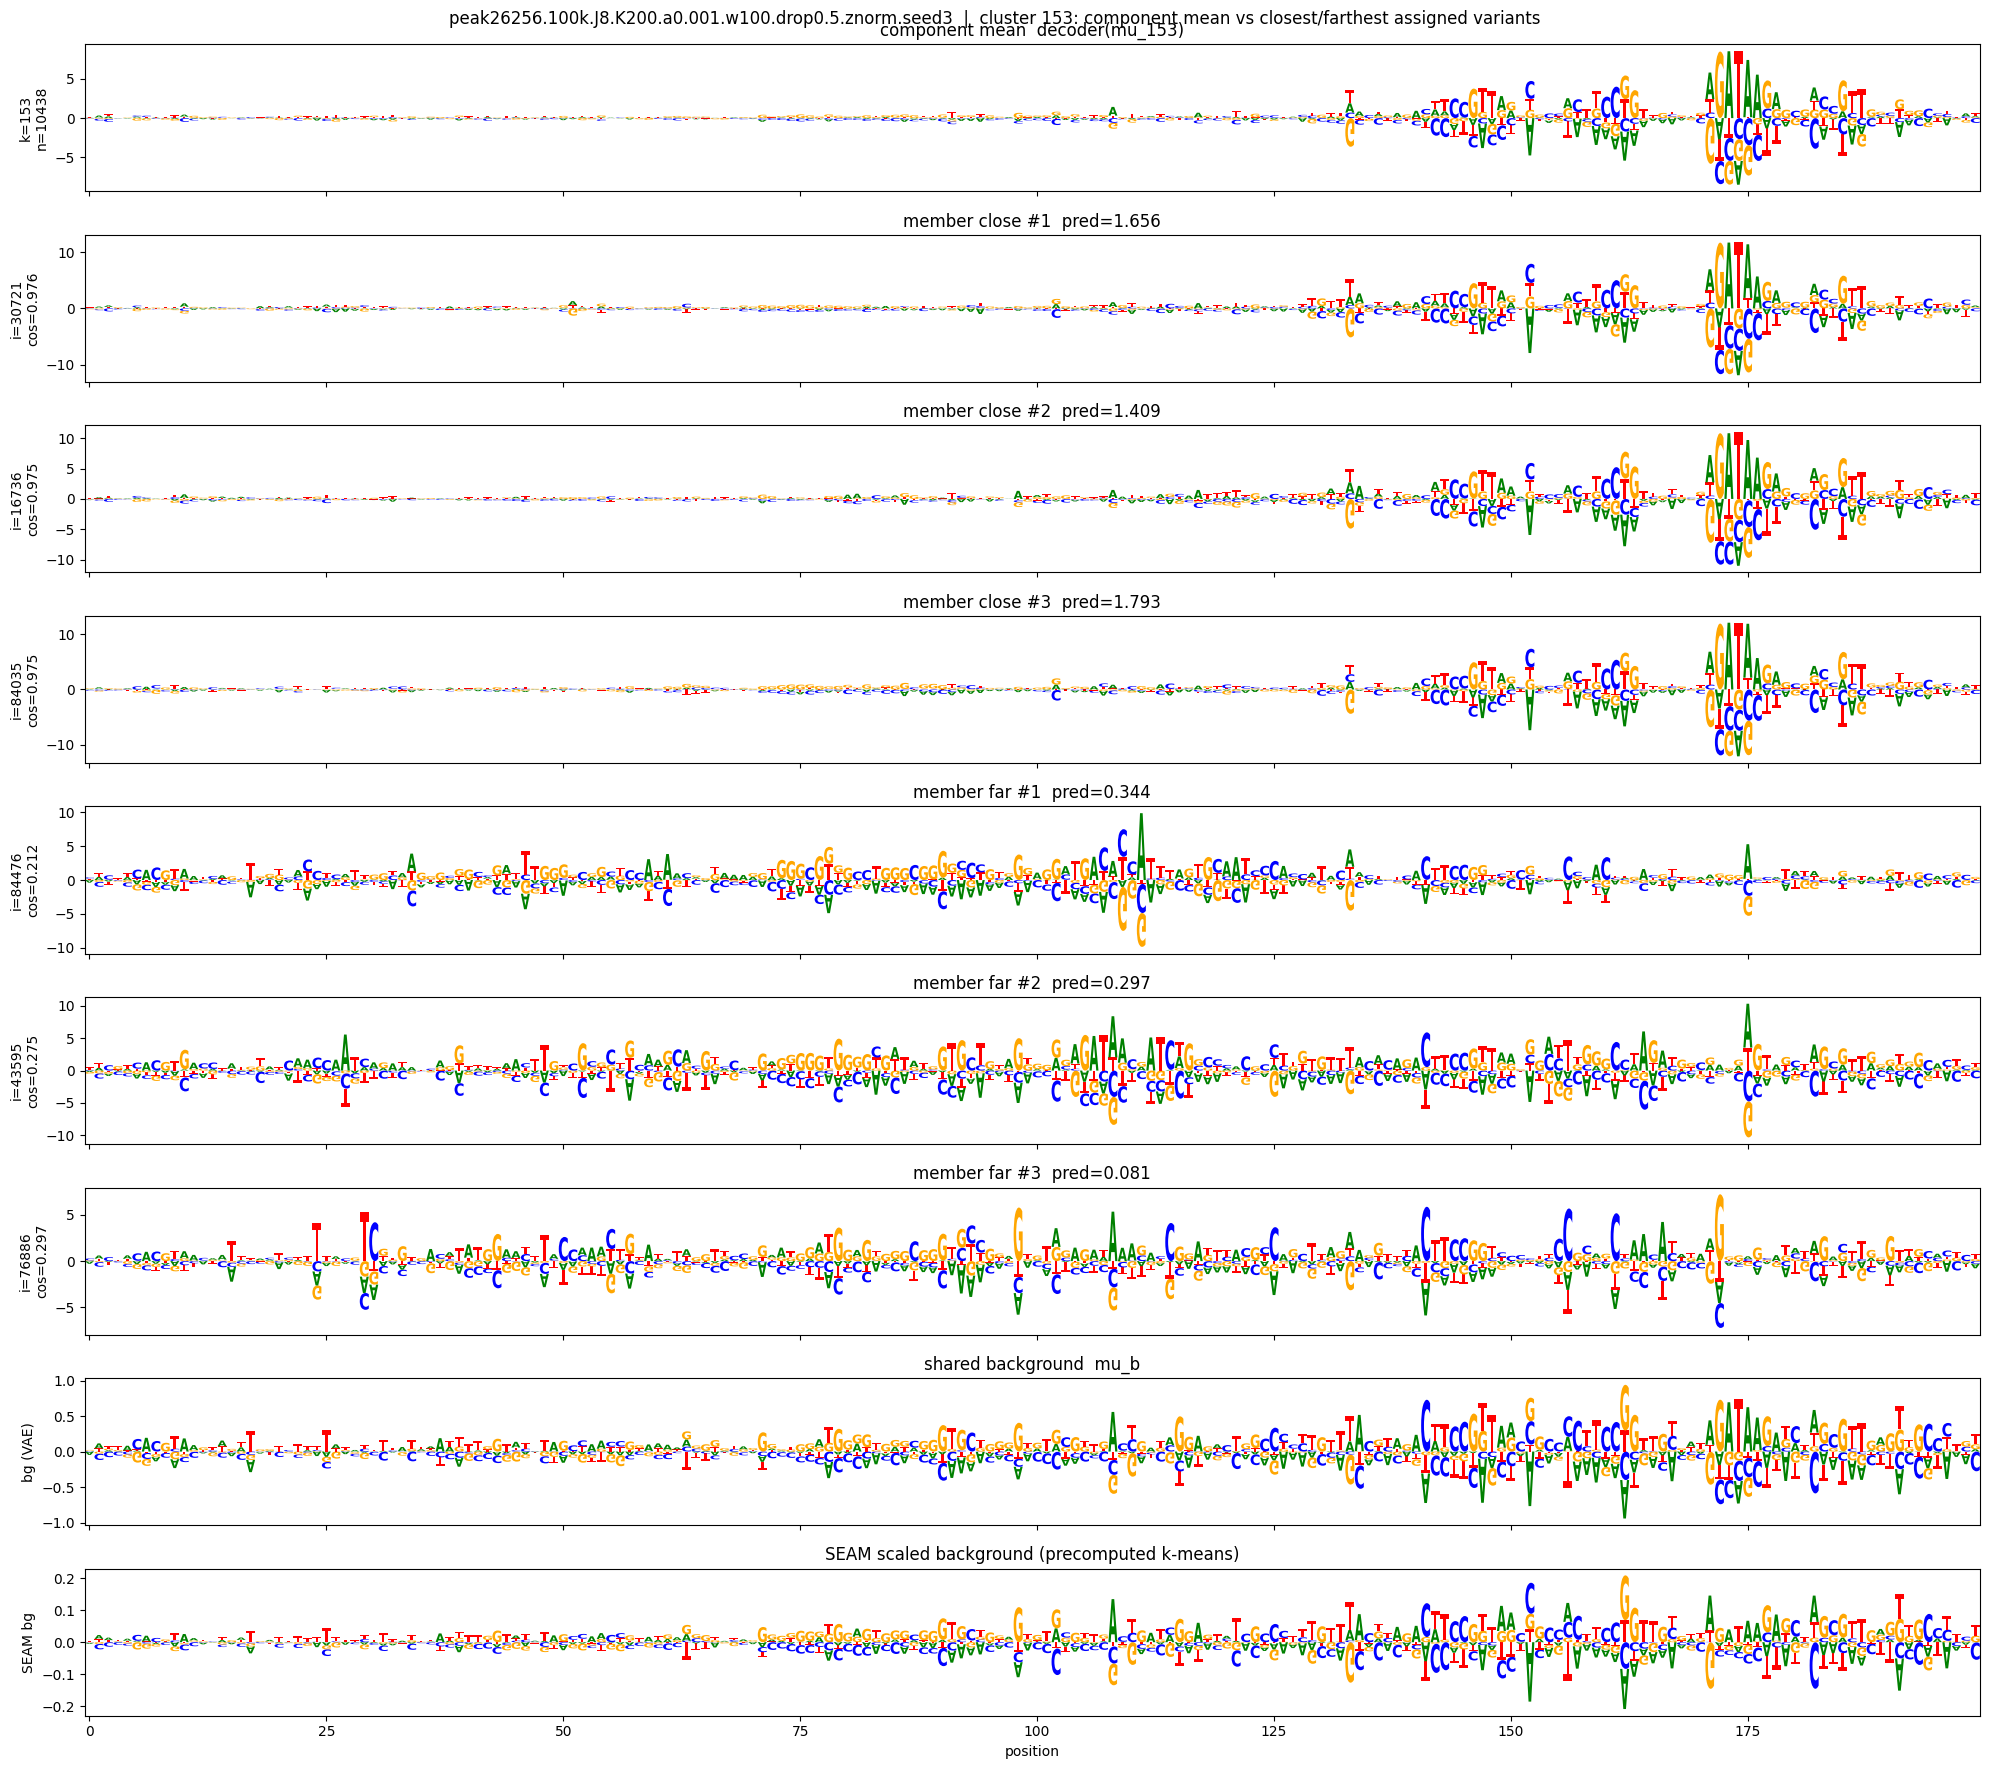

In [19]:
# ----- inspect ONE cluster: its component mean mu_k vs the variants hard-assigned to it -----
# (within-cluster spread: 3 closest + 3 farthest member maps to the component mean, by cosine)
sel_k = int(np.argmax(Nk))        # <-- pick a cluster here (default: largest)

members = np.where(hard == sel_k)[0]                      # variants hard-assigned to this cluster
with torch.no_grad():
    comp_fg = model.dec(model.mu_c[sel_k:sel_k+1].to(device)).cpu().numpy().reshape(L, 4)
    bg_mean = model.mu_b.detach().cpu().numpy().reshape(L, 4)

# cosine of each member's raw attribution map to the component mean foreground
c_vec = comp_fg.ravel(); c_vec = c_vec / (np.linalg.norm(c_vec) + 1e-12)
m_vec = X[members]; m_vec = m_vec / (np.linalg.norm(m_vec, axis=1, keepdims=True) + 1e-12)
cos   = m_vec @ c_vec                                     # (n_members,)
rank  = np.argsort(-cos)                                   # high -> low similarity
near  = members[rank[:3]]                                  # 3 most typical members
far   = members[rank[-3:][::-1]]                           # 3 most atypical members (farthest first)
cos_of = dict(zip(members.tolist(), cos.tolist()))

seam_dir_pk = f"{seam_dir}/foregrounds{suffix}/{peak}"
seam_bg = np.load(f"{seam_dir_pk}/average_background_scaled.npy")        # SEAM scaled background

panels  = [(comp_fg, f"k={sel_k}\nn={len(members)}", f"component mean  decoder(mu_{sel_k})")]
panels += [(X[i].reshape(L, 4), f"i={i}\ncos={cos_of[i]:.3f}", f"member close #{n+1}  pred={predictions[i]:.3f}") for n, i in enumerate(near)]
panels += [(X[i].reshape(L, 4), f"i={i}\ncos={cos_of[i]:.3f}", f"member far #{n+1}  pred={predictions[i]:.3f}") for n, i in enumerate(far)]
panels += [(bg_mean, "bg (VAE)", "shared background  mu_b"),
           (seam_bg, "SEAM bg",  "SEAM scaled background (precomputed k-means)")]

fig, axes = plt.subplots(len(panels), 1, figsize=(20, 2.0*len(panels)), sharex=True)
for ax, (m, ylab, title) in zip(axes, panels):
    fast_logo(m, ax=ax); ax.set_ylabel(ylab); ax.set_title(title)
axes[-1].set_xlabel("position")
fig.suptitle(f"{hp_tag}  |  cluster {sel_k}: component mean vs closest/farthest assigned variants")
plt.tight_layout(); plt.show()